In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA           # modern API
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX


import warnings
warnings.filterwarnings("ignore")

print("pandas:", pd.__version__)
import statsmodels as sm
print("statsmodels:", sm.__version__)

pandas: 2.0.3
statsmodels: 0.14.0


In [39]:
# =============================== FULL PIPELINE (Steps 1 → 6) ===============================
from __future__ import annotations

# ------------------------------- Imports -----------------------------------
import re
from dataclasses import dataclass
from typing import Optional, Dict, Any, List, Tuple, Sequence, Set

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf, plot_pacf as sm_plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, normal_ad
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.graphics.gofplots import qqplot

# ----------------------------- Data containers -----------------------------
@dataclass
class TransformMeta:
    method: str = "none"         # "none" | "log1p_shift" | "asinh"
    shift: float = 0.0           # used only for log1p_shift
    notes: str = ""

@dataclass
class DifferencingMeta:
    d: int = 0                   # non-seasonal differences
    D: int = 0                   # seasonal differences
    m: Optional[int] = None      # seasonal period (None if not seasonal)
    kept_tail: Dict[str, Any] = None  # values needed to invert differencing later

@dataclass
class ADFResult:
    statistic: float
    pvalue: float
    usedlag: int
    nobs: int
    critical_values: Dict[str, float]
    icbest: Optional[float]
    passed: bool                 # True if pvalue < alpha

@dataclass
class StationarityResult:
    y_stationary: pd.Series
    adf_before: Optional[ADFResult]
    adf_after: Optional[ADFResult]
    transform: TransformMeta
    differencing: DifferencingMeta

@dataclass
class ForecastIntent:
    mode: str                 # "chart" | "table" | "value"
    h: int                    # horizon in steps (0 if 'date' given)
    conf: float               # e.g., 0.90, 0.95
    date: Optional[pd.Timestamp]
    note: str = ""

# ----------------------------- Common utilities ----------------------------
def mape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true, dtype=float); y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > eps)
    if mask.sum() == 0: return np.inf
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)

def run_adf(y: pd.Series, alpha: float = 0.05, autolag: str = "AIC", maxlag: Optional[int] = None) -> Optional[ADFResult]:
    y = y.dropna()
    if len(y) < 10:
        return None
    try:
        stat, pval, usedlag, nobs, crit, icbest = adfuller(y.values, autolag=autolag, maxlag=maxlag)
    except Exception:
        return None
    return ADFResult(stat, pval, usedlag, nobs, crit, icbest, pval < alpha)

def choose_variance_stabilizer(y: pd.Series, skew_threshold: float = 0.75) -> TransformMeta:
    y = y.dropna()
    if len(y) == 0:
        return TransformMeta()
    skew = float(pd.Series(y).skew())
    if abs(skew) < skew_threshold:
        return TransformMeta(method="none", notes=f"abs(skew)={abs(skew):.2f} < {skew_threshold}")
    if (y > 0).all():
        return TransformMeta(method="log1p_shift", shift=0.0, notes=f"positive series; skew={skew:.2f}")
    return TransformMeta(method="asinh", notes=f"mixed signs; skew={skew:.2f}")

def apply_transform(y: pd.Series, meta: TransformMeta) -> pd.Series:
    if meta.method == "none":
        return y.copy()
    if meta.method == "log1p_shift":
        shift = meta.shift
        if (y <= 0).any():
            shift = max(shift, 1.0 - float(y.min()))
            meta.shift = shift
        return np.log1p(y + shift)
    if meta.method == "asinh":
        return np.arcsinh(y)
    raise ValueError(f"Unknown transform: {meta.method}")

def invert_transform(y_trans: pd.Series, meta: TransformMeta) -> pd.Series:
    if meta.method == "none":
        return y_trans.copy()
    if meta.method == "log1p_shift":
        return np.expm1(y_trans) - meta.shift
    if meta.method == "asinh":
        return np.sinh(y_trans)
    raise ValueError(f"Unknown transform: {meta.method}")

def guess_seasonal_period(index: pd.DatetimeIndex) -> Optional[int]:
    if not isinstance(index, pd.DatetimeIndex) or index.freq is None:
        return None
    f = index.freqstr.upper()
    if any(k in f for k in ["M", "MS"]):  return 12
    if "Q" in f:                          return 4
    if "W" in f:                          return 52
    if "D" in f:                          return 7
    if "H" in f:                          return 24
    if "MIN" in f:                        return 60
    return None

def _conf_band(n: int, z: float = 1.96) -> float:
    return z / np.sqrt(max(1, n))

# ------------------------------- Step 1 ------------------------------------
def csv_reader_6(
    csv: pd.DataFrame | str,
    time_column_name: Optional[str],
    target_column_name: str,
    date_format: Optional[str] = None,
    aggregate: str = "last",  # "last" | "mean" | "sum"
) -> pd.Series:
    df = csv.copy() if isinstance(csv, pd.DataFrame) else pd.read_csv(csv)

    # Decide time source
    use_index_as_time = False
    if time_column_name is None:
        use_index_as_time, raw = True, pd.Index(df.index).astype(str)
    elif time_column_name in df.columns:
        raw = df[time_column_name].astype(str).str.strip()
    elif (df.index.name == time_column_name
          or df.columns.name == time_column_name
          or pd.api.types.is_datetime64_any_dtype(df.index)):
        use_index_as_time, raw = True, pd.Index(df.index).astype(str)
    else:
        maybe = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]
        if len(maybe) == 1:
            time_column_name = maybe[0]
            raw = df[time_column_name].astype(str).str.strip()
        else:
            use_index_as_time, raw = True, pd.Index(df.index).astype(str)

    # Parse datetimes
    if date_format:
        dt_parsed = pd.to_datetime(raw, format=date_format, errors='coerce', utc=True)
    else:
        def _first_second(s_):
            s_ = "" if pd.isna(s_) else str(s_)
            toks = re.findall(r"\d+", s_)
            for i, tok in enumerate(toks):
                if len(tok) == 4:
                    try:
                        yr = int(tok)
                        if 1900 <= yr <= 2100:
                            toks = toks[:i] + toks[i+1:]
                            break
                    except Exception:
                        pass
            f = int(toks[0]) if len(toks) > 0 else np.nan
            sc = int(toks[1]) if len(toks) > 1 else np.nan
            return f, sc
        fs = pd.Series(raw).apply(_first_second).apply(pd.Series)
        fs.columns = ["first", "second"]
        us = ((fs["first"] <= 12) & (fs["second"] > 12)).sum()
        eu = ((fs["first"] > 12) & (fs["second"] <= 12)).sum()
        dayfirst = bool(eu > us)
        dt_parsed = pd.to_datetime(raw, dayfirst=dayfirst, errors='coerce', utc=True)

    # Normalize tz: UTC → naive
    if isinstance(dt_parsed, pd.Series):
        if getattr(dt_parsed.dt, "tz", None) is not None:
            dt_parsed = dt_parsed.dt.tz_convert("UTC").dt.tz_localize(None)
        else:
            dt_parsed = dt_parsed.dt.tz_localize(None) if hasattr(dt_parsed.dt, "tz_localize") else dt_parsed
    else:
        if getattr(dt_parsed, "tz", None) is not None:
            dt_parsed = dt_parsed.tz_convert("UTC").tz_localize(None)

    # Attach time index
    if use_index_as_time:
        df = df.copy()
        df.index = pd.DatetimeIndex(dt_parsed)
        df.index.name = df.index.name or time_column_name or "time"
    else:
        df[time_column_name] = pd.DatetimeIndex(dt_parsed)
        df = df.set_index(time_column_name)

    # Drop NaT, sort
    df = df.loc[~df.index.isna()].sort_index()

    # Target
    if target_column_name not in df.columns:
        if len(df.columns) == 1:
            target_column_name = df.columns[0]
        else:
            raise KeyError(f"'{target_column_name}' not in columns: {list(df.columns)}")

    vals = pd.to_numeric(df[target_column_name], errors="coerce")
    if aggregate == "last":
        s = vals.groupby(level=0).last()
    elif aggregate == "mean":
        s = vals.groupby(level=0).mean()
    elif aggregate == "sum":
        s = vals.groupby(level=0).sum()
    else:
        raise ValueError("aggregate must be one of: 'last', 'mean', 'sum'")
    s = s.dropna()

    # Infer frequency
    freq = pd.infer_freq(s.index)
    if freq is None and len(s) >= 3:
        deltas = s.index.to_series().diff().dropna()
        if not deltas.empty:
            try:
                mode_delta = deltas.mode().iloc[0]
            except Exception:
                mode_delta = deltas.value_counts().idxmax()
            try:
                from pandas.tseries.frequencies import to_offset
                freq = to_offset(mode_delta).freqstr
            except Exception:
                freq = None

    s.attrs["inferred_freq"] = freq
    if freq is not None:
        try:
            s.index = pd.DatetimeIndex(s.index, freq=freq)
        except ValueError:
            pass

    return s

# ------------------------------- Step 2 ------------------------------------
def _difference(y: pd.Series, lag: int) -> pd.Series:
    return y.diff(lag)

def _need_seasonal_diff(y: pd.Series, m: int) -> bool:
    y = y.dropna()
    n = len(y)
    if n < m + 5:
        return False
    acf_vals = acf(y, nlags=m, fft=True)
    band = _conf_band(n, z=1.96)
    return abs(acf_vals[m]) > band

def make_stationary(
    y: pd.Series,
    alpha: float = 0.05,
    max_d: int = 2,
    seasonal_period: Optional[int] = None,
    try_variance_stabilize: bool = True,
) -> StationarityResult:
    y = y.sort_index().astype("float").copy()
    adf0 = run_adf(y, alpha=alpha)

    tmeta = TransformMeta()
    y_t = y.copy()
    if try_variance_stabilize:
        tmeta = choose_variance_stabilizer(y_t)
        y_t = apply_transform(y_t, tmeta)

    if seasonal_period is None and isinstance(y.index, pd.DatetimeIndex):
        seasonal_period = guess_seasonal_period(y.index)

    D = 0
    kept_tail: Dict[str, Any] = {
        "orig_last": y.iloc[-1] if len(y) else None,
        "last_values_for_diff": {},
        "m": seasonal_period,
    }

    if seasonal_period and _need_seasonal_diff(y_t, seasonal_period):
        kept_tail["last_values_for_diff"]["seasonal"] = list(y_t.iloc[-seasonal_period:])
        y_t = _difference(y_t, seasonal_period)
        D = 1

    d = 0
    for _ in range(max_d):
        adf_now = run_adf(y_t, alpha=alpha)
        if adf_now and adf_now.passed:
            break
        kept_tail["last_values_for_diff"].setdefault("nonseasonal", []).append(float(y_t.iloc[-1]))
        y_t = _difference(y_t, 1)
        d += 1

    y_t = y_t.dropna()
    adf1 = run_adf(y_t, alpha=alpha)

    dmeta = DifferencingMeta(d=d, D=D, m=seasonal_period, kept_tail=kept_tail)

    return StationarityResult(
        y_stationary=y_t,
        adf_before=adf0,
        adf_after=adf1,
        transform=tmeta,
        differencing=dmeta,
    )

def invert_differences(y_diff: pd.Series, dmeta: DifferencingMeta) -> pd.Series:
    y_rec = y_diff.copy()
    if dmeta.d > 0:
        last_vals = dmeta.kept_tail.get("last_values_for_diff", {}).get("nonseasonal", [])
        for last in reversed(last_vals):
            y_rec = y_rec.cumsum() + last
    if dmeta.D == 1 and dmeta.m:
        seasonal_tail = dmeta.kept_tail.get("last_values_for_diff", {}).get("seasonal", [])
        if len(seasonal_tail) == dmeta.m:
            rec_vals = []
            hist = seasonal_tail.copy()
            for val in y_rec.values:
                base = hist[-dmeta.m]
                rec = val + base
                rec_vals.append(rec)
                hist.append(rec)
            y_rec = pd.Series(rec_vals, index=y_rec.index)
    return y_rec

def invert_all(y_stationary: pd.Series, transform: TransformMeta, dmeta: DifferencingMeta) -> pd.Series:
    return invert_transform(invert_differences(y_stationary, dmeta), transform)

def ensure_stationarity_from_csv(
    csv: pd.DataFrame | str,
    time_column_name: Optional[str],
    target_column_name: str,
    date_format: Optional[str] = None,
    aggregate: str = "last",
    adf_alpha: float = 0.05,
    max_d: int = 2,
    seasonal_period: Optional[int] = None,
    try_variance_stabilize: bool = True,
    compute_lag_suggestions: bool = True,
    nlags: int = 48,
) -> Tuple[pd.Series, StationarityResult, Optional[Dict[str, Any]]]:
    s = csv_reader_6(csv, time_column_name, target_column_name, date_format, aggregate)
    stat = make_stationary(s, alpha=adf_alpha, max_d=max_d, seasonal_period=seasonal_period,
                           try_variance_stabilize=try_variance_stabilize)
    lag_info = None
    if compute_lag_suggestions:
        lag_info = {"nlags": nlags, **lags_for_order_suggestion(stat.y_stationary, nlags=nlags)}
    return s, stat, lag_info

# ------------------------------- Step 3 ------------------------------------
def _max_pacf_lags(n: int) -> int:
    return max(1, (n - 1) // 2)

def significant_lags(y: pd.Series, nlags: int = 40) -> Dict[str, Any]:
    y = y.dropna()
    n = len(y)
    if n < 20:
        return {"acf": [], "pacf": [], "nlags_used": 0, "nlags_requested": nlags, "note": "n<20; insufficient data"}
    nlags_cap = _max_pacf_lags(n)
    nlags_used = int(min(nlags, nlags_cap))
    band = _conf_band(n, z=1.96)
    acf_vals = acf(y, nlags=nlags_used, fft=True)
    pacf_vals = pacf(y, nlags=nlags_used, method="ywm")
    acf_sig  = [lag for lag in range(1, len(acf_vals))  if abs(acf_vals[lag])  > band]
    pacf_sig = [lag for lag in range(1, len(pacf_vals)) if abs(pacf_vals[lag]) > band]
    note = f"nlags capped from {nlags} to {nlags_used} for n={n}" if nlags_used < nlags else None
    return {"acf": acf_sig, "pacf": pacf_sig, "nlags_used": nlags_used, "nlags_requested": nlags, "note": note}

def lags_for_order_suggestion(y_stationary: pd.Series, nlags: int = 40, alpha: float = 0.05) -> Dict[str, Any]:
    y_stationary = y_stationary.dropna()
    n = len(y_stationary)
    if n < 20:
        return {"acf_lags": [], "pacf_lags": [], "ci_band": None, "n": n,
                "nlags_used": 0, "nlags_requested": nlags, "note": "n<20; insufficient data"}
    sig  = significant_lags(y_stationary, nlags=nlags)
    band = _conf_band(n, z=1.96)
    return {
        "acf_lags": sig["acf"], "pacf_lags": sig["pacf"], "ci_band": band, "n": n,
        "nlags_used": sig["nlags_used"], "nlags_requested": sig["nlags_requested"], "note": sig.get("note")
    }

def _auto_nlags(n: int) -> int:
    return max(10, int(2 * np.sqrt(max(1, n))))

def acf_pacf_summary(y_stationary: pd.Series, nlags: int | str = "auto") -> Dict[str, Any]:
    n = len(y_stationary.dropna())
    if isinstance(nlags, str) and nlags.lower() == "auto": nlags = _auto_nlags(n)
    info = lags_for_order_suggestion(y_stationary, nlags=int(nlags))
    return {
        "n": info.get("n", n), "ci_band": info.get("ci_band"),
        "acf_lags": info.get("acf_lags", []), "pacf_lags": info.get("pacf_lags", []),
        "nlags_used": info.get("nlags_used", 0), "nlags_requested": info.get("nlags_requested", int(nlags)),
        "note": info.get("note"),
    }

def _dominant_period_from_sig_lags(sig_lags: Sequence[int], max_m: int = 60) -> Optional[int]:
    sig = [int(x) for x in sig_lags if int(x) > 1]
    if len(sig) < 3: return None
    best_m, best_hits = None, 0
    for m in range(2, max_m + 1):
        hits = sum(1 for x in sig if x % m == 0)
        if hits > best_hits:
            best_m, best_hits = m, hits
    if best_m is None: return None
    return best_m if best_hits / max(1, len(sig)) >= 0.5 else None

def _seasonality_preference(acf_lags: Sequence[int], pacf_lags: Sequence[int], m: int) -> str:
    acf_hits  = sum(1 for x in acf_lags  if x % m == 0)
    pacf_hits = sum(1 for x in pacf_lags if x % m == 0)
    if acf_hits > pacf_hits * 1.2: return "MA"
    if pacf_hits > acf_hits * 1.2: return "AR"
    return "mixed"

def suggest_sarimax_candidates_pattern_aware(
    stat: StationarityResult, nlags: int | str = "auto", max_pq: int = 1, seasonal_try_alt: bool = True
) -> Dict[str, Any]:
    y_st = stat.y_stationary.dropna()
    info = acf_pacf_summary(y_st, nlags=nlags)
    acf_lags = info["acf_lags"]; pacf_lags = info["pacf_lags"]
    m_dom = _dominant_period_from_sig_lags(acf_lags + pacf_lags, max_m=60) or stat.differencing.m
    info["m_from_pattern"] = m_dom
    if m_dom and info["nlags_used"] > 3 * m_dom:
        info["note"] = (info.get("note") or "") + f" | nlags trimmed to 3*m={3*m_dom}"

    p_cands, q_cands = [0,1], [0,1]
    small_p = [x for x in pacf_lags if 1 < x <= 3]
    small_q = [x for x in acf_lags  if 1 < x <= 3]
    if small_p and 2 not in p_cands and max_pq >= 2: p_cands.append(2)
    if small_q and 2 not in q_cands and max_pq >= 2: q_cands.append(2)

    d = stat.differencing.d; D = stat.differencing.D; m = m_dom or stat.differencing.m
    if m and m > 1:
        pref = _seasonality_preference(acf_lags, pacf_lags, m)
        if pref == "AR":   P_cands, Q_cands = [0,1], [0]
        elif pref == "MA": P_cands, Q_cands = [0], [0,1]
        else:              P_cands, Q_cands = [0,1], ([0,1] if seasonal_try_alt else [0])
        seasonality_check = {"has_seasonality": True, "m": m, "preference": pref}
    else:
        P_cands, Q_cands, seasonality_check = [0], [0], {"has_seasonality": False, "m": m, "preference": "none"}

    cand_set: Set[Tuple[Tuple[int,int,int], Tuple[int,int,int,int]]] = set()
    for p in p_cands:
        for q in q_cands:
            for P in P_cands:
                for Q in Q_cands:
                    cand_set.add(((int(p), int(d), int(q)), (int(P), int(D), int(Q), int(m or 0))))
    cand_set.add(((0,int(d),0),(0,int(D),0,int(m or 0))))

    def _order_key(c):
        (p, d_, q), (P, D_, Q, m_) = c
        return (p + q + P + Q, p, q, P, Q)
    candidates = sorted(list(cand_set), key=_order_key)

    return {"d": d, "D": D, "m": m, "summary": info, "seasonality_check": seasonality_check,
            "candidates": candidates, "p_cands": p_cands, "q_cands": q_cands, "P_cands": P_cands, "Q_cands": Q_cands}

def plot_acf_pacf(y_stationary: pd.Series, nlags: int | str = "auto", title_prefix: str = "Step 3"):
    n = len(y_stationary.dropna())
    if isinstance(nlags, str) and nlags.lower() == "auto": nlags = _auto_nlags(n)
    fig = plt.figure(figsize=(10, 8))
    ax1 = fig.add_subplot(2,1,1); sm_plot_acf(y_stationary.dropna(), lags=int(nlags), ax=ax1)
    ax1.set_title(f"{title_prefix} — ACF (nlags={int(nlags)})")
    ax2 = fig.add_subplot(2,1,2); sm_plot_pacf(y_stationary.dropna(), lags=int(nlags), method="ywm", ax=ax2)
    ax2.set_title(f"{title_prefix} — PACF (nlags={int(nlags)})")
    plt.tight_layout(); plt.show()

def suggest_sarimax_candidates(stat: StationarityResult, nlags: int | str = "auto",
                               max_p: int = 3, max_q: int = 3, max_P: int = 1, max_Q: int = 1):
    return suggest_sarimax_candidates_pattern_aware(stat, nlags=nlags, max_pq=min(max_p, max_q, 2), seasonal_try_alt=True)

# ------------------------------- Step 4 ------------------------------------
def _prepare_endog_for_model(y_orig: pd.Series, transform: TransformMeta) -> pd.Series:
    y = y_orig.sort_index().astype(float)
    return apply_transform(y, transform)

def _default_val_h_fast(n: int, m: Optional[int]) -> int:
    base = 16
    if m and m > 1:
        base = max(base, 2 * m)
    return int(min(base, max(n // 3, 8)))

def _coef_significance_ok(res, alpha: float = 0.05) -> Dict[str, Any]:
    try:
        pv = res.pvalues
        names = list(pv.index)
        skip_tokens = ("sigma2","measurement","state","variance")
        keep_mask = [all(tok.lower() not in name.lower() for tok in names if tok) for name in names]
        pv_keep = pv[np.array(keep_mask)]
        return {"sig_share": float((pv_keep < alpha).mean()) if len(pv_keep)>0 else np.nan,
                "min_p": float(pv_keep.min()) if len(pv_keep)>0 else np.nan,
                "n_params": int(len(pv_keep))}
    except Exception:
        return {"sig_share": np.nan, "min_p": np.nan, "n_params": 0}

def _residual_diagnostics(residuals: pd.Series, lags: int = 12) -> Dict[str, Any]:
    resid = pd.Series(residuals).dropna()
    out: Dict[str, Any] = {"n": int(len(resid))}
    if len(resid) < max(12, lags + 2):
        out.update({"warning": f"short residual series (n={len(resid)})",
                    "lb_pvalue": np.nan, "arch_pvalue": np.nan, "dw": np.nan,
                    "jb_pvalue": np.nan, "ad_pvalue": np.nan})
        return out
    try:
        lb = acorr_ljungbox(resid, lags=[min(lags, len(resid)//4)], return_df=True)
        out["lb_pvalue"] = float(lb["lb_pvalue"].iloc[-1])
    except Exception: out["lb_pvalue"] = np.nan
    try:
        arch_stat, arch_p, _, _ = het_arch(resid, nlags=min(lags, 12))
        out["arch_pvalue"] = float(arch_p)
    except Exception: out["arch_pvalue"] = np.nan
    try: out["dw"] = float(durbin_watson(resid))
    except Exception: out["dw"] = np.nan
    try:
        jb_stat, jb_p, _, _ = jarque_bera(resid); out["jb_pvalue"] = float(jb_p)
    except Exception: out["jb_pvalue"] = np.nan
    try:
        ad_stat, ad_p = normal_ad(resid); out["ad_pvalue"] = float(ad_p)
    except Exception: out["ad_pvalue"] = np.nan
    return out

def _passes_diagnostics(diag: Dict[str, Any], alpha: float = 0.05) -> bool:
    lb_ok   = (diag.get("lb_pvalue")   is not None) and (diag.get("lb_pvalue", 0.0)   > alpha)
    arch_ok = (diag.get("arch_pvalue") is not None) and (diag.get("arch_pvalue", 0.0) > alpha)
    return bool(lb_ok and arch_ok)

def _fit_one_model(train_T: pd.Series, order, seasonal_order, trend, enforce_stationarity, enforce_invertibility):
    model = SARIMAX(train_T, order=order, seasonal_order=seasonal_order, trend=trend,
                    enforce_stationarity=enforce_stationarity, enforce_invertibility=enforce_invertibility)
    res = model.fit(disp=False, method="lbfgs", maxiter=200)
    return res

def fit_sarimax_grid_fast(
    s_orig: pd.Series,
    stat: StationarityResult,
    candidates: List[Tuple[Tuple[int,int,int], Tuple[int,int,int,int]]],
    val_h: Optional[int] = None,
    enforce_stationarity: bool = True,
    enforce_invertibility: bool = True,
    trends: Optional[List[str]] = None,
    alpha: float = 0.05,
    diag_lags: int = 12,
    verbose: bool = True,
) -> Dict[str, Any]:
    if trends is None: trends = ['n','c']
    yT = _prepare_endog_for_model(s_orig, stat.transform)
    yT = yT.asfreq(s_orig.index.freq) if getattr(s_orig.index, "freq", None) is not None else yT
    n = len(yT.dropna())
    if n < 20: raise ValueError(f"Series too short for Step 4 (n={n})")
    if val_h is None: val_h = _default_val_h_fast(n, stat.differencing.m)
    train = yT.iloc[:-val_h]; valid_orig = s_orig.iloc[-val_h:]

    results: List[Dict[str, Any]] = []
    for ((p, d, q), (P, D, Q, m)) in candidates:
        for trend in trends:
            try:
                res = _fit_one_model(train, (p,d,q), (P,D,Q,m or 0), trend,
                                     enforce_stationarity, enforce_invertibility)
            except Exception as e:
                if verbose: print(f"[fit] {(p,d,q)}x({P},{D},{Q},{m}) trend={trend} — ❌ {e}")
                results.append({"order":(p,d,q),"seasonal_order":(P,D,Q,m),"trend":trend,"fit_ok":False,"error":str(e)})
                continue

            # Validation forecast (back-transform to original scale)
            try:
                fc = res.get_forecast(steps=val_h)
                mean_T = fc.predicted_mean
                mean_orig = invert_transform(mean_T, stat.transform)
                mean_orig.index = valid_orig.index
                mape_val = mape(valid_orig.values, mean_orig.values)
            except Exception:
                mape_val = np.inf

            # Residuals + diagnostics
            try:
                resid = res.filter_results.standardized_forecasts_error[0]
                resid_series = pd.Series(resid, index=train.index).dropna()
            except Exception:
                resid_series = pd.Series([], dtype=float)
            diag = _residual_diagnostics(resid_series, lags=diag_lags)
            coef = _coef_significance_ok(res, alpha=alpha)
            passed = _passes_diagnostics(diag, alpha=alpha)

            if verbose:
                print(f"[fit] {(p,d,q)}x({P},{D},{Q},{m}) trend={trend} — "
                      f"AIC={res.aic:.1f}, MAPE_val={mape_val:.2f}% LB_p={diag.get('lb_pvalue')} ARCH_p={diag.get('arch_pvalue')} "
                      f"{'✅' if passed else '⚠️'}")

            results.append({
                "order": (p,d,q), "seasonal_order": (P,D,Q,m), "trend": trend,
                "fit_ok": True, "aic": float(res.aic), "mape_val": float(mape_val),
                "diagnostics": diag, "coef_signif": coef, "passed": passed, "result_obj": res
            })

    ok = [r for r in results if r.get("fit_ok")]
    passed = [r for r in ok if r.get("passed")]
    failed = [r for r in ok if not r.get("passed")]
    key = lambda r: (r["aic"], r["mape_val"])
    ranked = sorted(passed, key=key) + sorted(failed, key=key)

    # Flat-line guard
    def _is_all_zero_no_trend(r):
        (p,d,q) = r["order"]; (P,D,Q,m) = r["seasonal_order"]; tr = r.get("trend")
        return (p==0 and q==0 and P==0 and Q==0 and tr in (None, 'n'))

    if ranked and _is_all_zero_no_trend(ranked[0]):
        r0 = ranked[0]
        try:
            res_retry = _fit_one_model(train, r0["order"], r0["seasonal_order"], 'c',
                                       enforce_stationarity, enforce_invertibility)
            fc = res_retry.get_forecast(steps=val_h)
            mean_T = fc.predicted_mean
            mean_orig = invert_transform(mean_T, stat.transform)
            mean_orig.index = valid_orig.index
            mape_val = mape(valid_orig.values, mean_orig.values)
            diag = _residual_diagnostics(pd.Series(res_retry.filter_results.standardized_forecasts_error[0], index=train.index).dropna(), lags=diag_lags)
            coef = _coef_significance_ok(res_retry, alpha=alpha)
            passed_retry = _passes_diagnostics(diag, alpha=alpha)
            ranked.insert(0, {
                "order": r0["order"], "seasonal_order": r0["seasonal_order"], "trend": 'c',
                "fit_ok": True, "aic": float(res_retry.aic), "mape_val": float(mape_val),
                "diagnostics": diag, "coef_signif": coef, "passed": passed_retry, "result_obj": res_retry
            })
        except Exception:
            pass

    best = ranked[0] if ranked else (results[0] if results else None)
    return {"best": best, "ranked": ranked, "all_results": results, "val_h": val_h}

def build_best_model_from_suggestions(
    s: pd.Series,
    stat: StationarityResult,
    suggestions: Dict[str, Any],
    val_h: Optional[int] = None,
    verbose: bool = True,
) -> Dict[str, Any]:
    out = fit_sarimax_grid_fast(s_orig=s, stat=stat, candidates=suggestions["candidates"], val_h=val_h,
                                trends=['n','c'], verbose=verbose)
    best = out["best"]
    if verbose:
        if best and best.get("fit_ok"):
            (p,d,q) = best["order"]; (P,D,Q,m) = best["seasonal_order"]; tr = best.get("trend")
            print(f"✅ Best: {(p,d,q)}x({P},{D},{Q},{m}) trend={tr} AIC={best['aic']:.1f} "
                  f"MAPE_val={best['mape_val']:.2f}% LB_p={best['diagnostics'].get('lb_pvalue')} "
                  f"ARCH_p={best['diagnostics'].get('arch_pvalue')}")
        else:
            print("⚠️ No model fit successfully.")
    return out

# ------------------------------- Step 5 ------------------------------------
def validate_model(
    s: pd.Series,
    stat: StationarityResult,
    best_pack: Dict[str, Any],
    val_h: int,
    alpha: float = 0.05,
    plot: bool = True,
    figsize=(12,8)
) -> Dict[str, Any]:
    if not best_pack or not best_pack.get("fit_ok"):
        raise ValueError("No valid model provided for validation.")
    res = best_pack["result_obj"]

    # Residuals (standardized if available)
    try:
        resid = res.filter_results.standardized_forecasts_error[0]
        resid = pd.Series(resid, index=res.data.row_labels).dropna()
    except Exception:
        resid = pd.Series(res.resid).dropna()

    # Validation forecast (original scale)
    fc = res.get_forecast(steps=val_h)
    mean_T = fc.predicted_mean
    mean_orig = invert_transform(mean_T, stat.transform)
    valid_orig = s.iloc[-val_h:]
    mean_orig.index = valid_orig.index
    val_mape = mape(valid_orig.values, mean_orig.values)

    diag = _residual_diagnostics(resid, lags=min(12, val_h))
    coef = _coef_significance_ok(res, alpha=alpha)

    report = {"aic": float(getattr(res, "aic", np.nan)),
              "order": best_pack.get("order"),
              "seasonal_order": best_pack.get("seasonal_order"),
              "trend": best_pack.get("trend"),
              "coef_significance": coef, "resid_diag": diag,
              "val_mape": val_mape, "n_obs": int(len(s)), "val_h": int(val_h)}

    print("\n=== Step 5 Validation Report ===")
    print(f"Model: order={report['order']} seasonal={report['seasonal_order']} trend={report['trend']}")
    print(f"AIC={report['aic']:.1f}, Validation MAPE={report['val_mape']:.2f}%")
    print(f"Ljung–Box p={diag.get('lb_pvalue')} | ARCH p={diag.get('arch_pvalue')} | "
          f"JB p={diag.get('jb_pvalue')} | AD p={diag.get('ad_pvalue')} | DW={diag.get('dw')}")
    if diag.get("warning"): print("⚠️", diag["warning"])

    if plot:
        fig, axes = plt.subplots(2,2, figsize=figsize)
        resid.plot(ax=axes[0,0], title="Residuals")
        axes[0,1].hist(resid, bins=30); axes[0,1].set_title("Residual histogram")
        qqplot(resid, line='s', ax=axes[1,0]); axes[1,0].set_title("QQ plot")
        pd.plotting.autocorrelation_plot(resid, ax=axes[1,1]); axes[1,1].set_title("Residual ACF")
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(10,4))
        s.plot(label="observed")
        mean_orig.plot(label="forecast (val)", linestyle="--")
        plt.axvline(valid_orig.index[0], color="k", alpha=0.3)
        plt.legend(); plt.title("Validation forecast vs observed"); plt.tight_layout(); plt.show()

    return report

# ------------------------------- Step 6 ------------------------------------
# ----- Request parsing -----
def _infer_mode(text: str) -> str:
    t = text.lower()
    if any(k in t for k in ["value on","value at","predict on","predict at","what is","single value","point forecast"]):
        return "value"
    if any(k in t for k in ["table","tabular","csv","list values"]):
        return "table"
    if any(k in t for k in ["plot","graph","chart","visual"]):
        return "chart"
    return "chart"

def _parse_conf(text: str, default_conf: float = 0.95) -> float:
    t = text.lower()
    m = re.search(r'(\d{2})(?:\.\d+)?\s*%?\s*ci', t) or re.search(r'ci\s*[:=]?\s*(0\.\d+)', t)
    if m:
        g = m.group(1)
        v = float(g) / 100.0 if "%" in m.group(0) or len(g) == 2 else float(g)
        if 0.5 <= v < 0.999: return v
    return default_conf

def _parse_horizon(text: str, default_h: int, freq: Optional[str]) -> Tuple[int, Optional[pd.Timestamp], str]:
    t = text.lower().strip()
    m = re.search(r'(?:on|at|for)\s+([0-9]{4}[-/][0-9]{1,2}[-/][0-9]{1,2})', t)
    if m:
        try:  return 0, pd.to_datetime(m.group(1), errors="raise"), "explicit date parsed"
        except Exception: pass
    m = re.search(r'(?:next|forecast)\s+(\d+)\s*(period|step|steps|periods|days|day|weeks|week|months|month|years|year)?', t)
    if m: return int(m.group(1)), None, f"parsed next {m.group(1)} {m.group(2) or 'steps'}"
    m = re.search(r'(\d+)\s*(period|step|steps|periods|days|day|weeks|week|months|month|years|year)\b', t)
    if m: return int(m.group(1)), None, f"fallback horizon {m.group(1)}"
    return default_h, None, f"default horizon {default_h}"

def parse_forecast_request(request_text: str, s: pd.Series, default_h: int = 12, default_conf: float = 0.95) -> ForecastIntent:
    mode = _infer_mode(request_text)
    conf = _parse_conf(request_text, default_conf)
    freq = s.attrs.get("inferred_freq") or getattr(s.index, "freqstr", None)
    h, date, note = _parse_horizon(request_text, default_h=default_h, freq=freq)
    return ForecastIntent(mode=mode, h=int(max(0, h)), conf=float(conf), date=date, note=note)

# ----- Forecast core + index robustness -----
def _get_freq_str_from_series(s: pd.Series) -> Optional[str]:
    f = None
    try:
        f = getattr(s.index, "freqstr", None) or getattr(s.index, "inferred_freq", None)
    except Exception:
        f = None
    if not f:
        f = s.attrs.get("inferred_freq")
    if not f:
        try: f = pd.infer_freq(s.index)
        except Exception: f = None
    return f

def _steps_between_dates(last_ts: pd.Timestamp, target_date: pd.Timestamp, freq: Optional[str]) -> Optional[int]:
    if (not isinstance(last_ts, pd.Timestamp)) or (target_date is None) or (not freq): return None
    try:
        rng = pd.date_range(start=last_ts, end=target_date, freq=freq)
        return max(0, len(rng) - 1)
    except Exception:
        return None

def _coerce_forecast_index_datetime(
    s: pd.Series, mean_orig: pd.Series, conf_orig: pd.DataFrame, h: int
) -> tuple[pd.Series, pd.DataFrame]:
    if pd.api.types.is_datetime64_any_dtype(mean_orig.index): return mean_orig, conf_orig
    freq = _get_freq_str_from_series(s)
    if not freq: return mean_orig, conf_orig
    last_ts = s.index[-1]
    try:
        fut_idx = pd.date_range(start=last_ts, periods=h+1, freq=freq)[1:]
        mean_orig.index = fut_idx; conf_orig.index = fut_idx
    except Exception:
        pass
    return mean_orig, conf_orig

def produce_forecast(
    s: pd.Series,
    stat: StationarityResult,
    best_pack: Dict[str, Any],
    intent: ForecastIntent,
) -> Dict[str, Any]:
    freq = _get_freq_str_from_series(s)
    last_ts = s.index[-1]
    h = int(getattr(intent, "h", 1) or 1)
    target_date = getattr(intent, "date", None)
    if target_date is not None and h == 0:
        steps = _steps_between_dates(last_ts, target_date, freq)
        h = steps if steps is not None else 1
    if h <= 0: h = 1

    try:
        res = best_pack["result_obj"]
        fc = res.get_forecast(steps=h)
        mean_T = fc.predicted_mean
        conf_T = fc.conf_int(alpha=1.0 - getattr(intent, "conf", 0.95))
        mean_orig = invert_transform(mean_T, stat.transform)
        conf_orig = conf_T.copy()
        if conf_orig.shape[1] == 2:
            conf_orig.columns = ["lower y", "upper y"]
        else:
            conf_orig = conf_orig.rename(columns={conf_orig.columns[0]: "lower y", conf_orig.columns[-1]: "upper y"})
        # ensure datetime-like forecast index where feasible
        mean_orig, conf_orig = _coerce_forecast_index_datetime(s, mean_orig, conf_orig, h)
        try:
            mean_orig.index.freq = getattr(s.index, "freq", None)
            conf_orig.index.freq = getattr(s.index, "freq", None)
        except Exception:
            pass
        return {"ok": True, "used_model": True, "mean_orig": mean_orig, "conf_orig": conf_orig,
                "h": h, "note": "model forecast", "conf_level": float(getattr(intent, "conf", 0.95))}
    except Exception as e:
        fail_note = f"model forecast failed: {e}"

    # seasonal-naive fallback
    m = stat.differencing.m or 1
    future_idx = pd.date_range(start=last_ts, periods=h+1, freq=freq or "D")[1:] if isinstance(last_ts, pd.Timestamp) else pd.RangeIndex(0, h)
    vals = []
    for i in range(1, h+1):
        try: vals.append(float(s.iloc[-m + (i - 1)]))
        except Exception: vals.append(float(s.iloc[-1]))
    mean_orig = pd.Series(vals, index=future_idx)
    try:
        resid = (s[m:] - s.shift(m)[m:]).dropna(); se = float(resid.std())
    except Exception:
        se = float(np.std(np.diff(s.values)))
    z = 1.96
    conf_orig = pd.DataFrame({"lower y": mean_orig - z*se, "upper y": mean_orig + z*se}, index=mean_orig.index)
    return {"ok": True, "used_model": False, "mean_orig": mean_orig, "conf_orig": conf_orig,
            "h": h, "note": fail_note if 'fail_note' in locals() else "seasonal naive fallback", "conf_level": 0.95}

# ----- Rendering (chart/table/value) with forecast ≥ 20% of width -----
def _compute_recent_window_len(n_hist: int, h: int, min_share: float,
                               min_hist_pts: int = 30, max_hist_pts: Optional[int] = None) -> int:
    if h <= 0: h = 1
    needed = int(np.ceil(h * (1.0 - min_share) / max(min_share, 1e-6)))
    hist_window = max(min_hist_pts, needed)
    if max_hist_pts is not None:
        hist_window = min(hist_window, max_hist_pts)
    return int(min(hist_window, max(1, n_hist)))

def _y_limits_with_padding(series_list, pad_ratio: float = 0.10):
    y_min = np.inf; y_max = -np.inf
    for obj in series_list:
        if obj is None: continue
        vals = None
        if isinstance(obj, pd.Series):
            vals = obj.values
        elif isinstance(obj, pd.DataFrame):
            vals = obj.select_dtypes(include=[np.number]).values
        if vals is not None and len(vals):
            y_min = min(y_min, np.nanmin(vals))
            y_max = max(y_max, np.nanmax(vals))
    if not np.isfinite(y_min) or not np.isfinite(y_max): return None
    if y_min == y_max:
        delta = 1.0 if y_min == 0 else abs(y_min) * 0.05
        return (y_min - delta, y_max + delta)
    span = y_max - y_min; pad = span * pad_ratio
    return (y_min - pad, y_max + pad)

def render_forecast_chart(
    s: pd.Series,
    fc_pack: Dict[str, Any],
    title: Optional[str] = None,
    figsize=(11, 4),
    min_forecast_share: float = 0.20,   # <-- default 20% of the x-axis; set to 0.10 for 10%
    min_hist_pts: int = 30,
    max_hist_pts: Optional[int] = None,
    force_zoom: bool = True
):
    mean = fc_pack["mean_orig"]; conf = fc_pack["conf_orig"]; cl = fc_pack.get("conf_level", 0.95)
    if title is None: title = f"Forecast ({int(round(cl*100))}% CI)"
    n_hist = len(s); h = len(mean)
    hist_window = _compute_recent_window_len(n_hist, h, min_forecast_share,
                                             min_hist_pts=min_hist_pts, max_hist_pts=max_hist_pts)
    s_plot = s.iloc[-hist_window:] if hist_window < n_hist else s
    ylims = _y_limits_with_padding([s_plot, mean, conf], pad_ratio=0.10)

    plt.figure(figsize=figsize)
    s_plot.plot(label="observed", linewidth=1.8)
    mean.plot(label="forecast", linestyle="--", linewidth=2.4)
    if conf is not None:
        plt.fill_between(conf.index, conf["lower y"].values, conf["upper y"].values, alpha=0.22,
                         label=f"{int(round(cl*100))}% CI")
    try:
        cut = s.index[-1]; plt.axvline(cut, color="k", alpha=0.35, linewidth=1.0)
    except Exception:
        pass

    if force_zoom:
        try:
            x_min = s_plot.index[0]; x_max = mean.index[-1]
            plt.xlim(x_min, x_max)
        except Exception:
            pass

    if ylims is not None: plt.ylim(*ylims)
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def render_forecast_table(fc_pack: Dict[str, Any], head: int = 20) -> pd.DataFrame:
    df = pd.DataFrame({
        "forecast": fc_pack["mean_orig"],
        "lower": fc_pack["conf_orig"]["lower y"],
        "upper": fc_pack["conf_orig"]["upper y"],
    })
    display(df.head(head))
    return df

def render_forecast_value(
    s: pd.Series,
    fc_pack: Dict[str, Any],
    target_date: Optional[pd.Timestamp] = None
):
    mean = fc_pack["mean_orig"]; conf = fc_pack["conf_orig"]
    idx_to_use = 0
    if target_date is not None:
        if pd.api.types.is_datetime64_any_dtype(mean.index):
            pos = mean.index.get_indexer([pd.Timestamp(target_date)], method="nearest")
            idx_to_use = int(pos[0]) if pos.size else 0
        else:
            freq = _get_freq_str_from_series(s)
            last_ts = s.index[-1] if pd.api.types.is_datetime64_any_dtype(s.index) else None
            steps = _steps_between_dates(last_ts, pd.Timestamp(target_date), freq) if last_ts is not None else None
            if steps is not None and 0 <= steps-1 < len(mean): idx_to_use = steps-1
    ts = mean.index[idx_to_use]; val = float(mean.iloc[idx_to_use])
    lo = float(conf["lower y"].iloc[idx_to_use]); hi = float(conf["upper y"].iloc[idx_to_use])
    print(f"Predicted value @ {ts}: {val:.4g}  (CI: [{lo:.4g}, {hi:.4g}])")
    return ts, val, (lo, hi)

def fulfill_forecast_request(
    request_text: str,
    s: pd.Series,
    stat: StationarityResult,
    best_pack: Dict[str, Any],
    default_h: int = 12,
    default_conf: float = 0.95,
    render: bool = True,
    min_forecast_share: float = 0.20,   # <-- set to 0.10–0.20 per your preference
    **render_kwargs
) -> Dict[str, Any]:
    intent = parse_forecast_request(request_text, s=s, default_h=default_h, default_conf=default_conf)
    fc_pack = produce_forecast(s, stat, best_pack, intent)
    out = {"intent": intent.__dict__, "used_model": fc_pack["used_model"], "h": fc_pack["h"], "note": fc_pack["note"]}

    if intent.mode == "chart":
        if render:
            render_forecast_chart(
                s, fc_pack,
                title=f"Forecast ({int(100*intent.conf)}% CI)",
                min_forecast_share=min_forecast_share,
                **render_kwargs
            )
        out["result_type"] = "chart"; out["result"] = {"n_steps": int(fc_pack["h"])}
    elif intent.mode == "table":
        render_forecast_table(fc_pack, head=min(50, fc_pack["h"])) if render else None
        out["result_type"] = "table"; out["result"] = {"rows": int(fc_pack["h"])}
    else:
        ts, val, (lo, hi) = render_forecast_value(s, fc_pack, intent.date) if render else (None, None, (None,None))
        out["result_type"] = "value"; out["result"] = {"timestamp": (str(ts) if ts is not None else None),
                                                       "value": val, "ci": [lo, hi]}
    return out

# ---------------------------- Convenience helper ---------------------------
def forecast_fixed_horizon(
    s: pd.Series,
    stat: StationarityResult,
    best_pack: Dict[str, Any],
    steps: int = 12,
    conf: float = 0.95,
    mode: str = "chart",
    render: bool = True,
    min_forecast_share: float = 0.20,
) -> Dict[str, Any]:
    intent = ForecastIntent(mode=mode, h=int(steps), conf=float(conf), date=None, note="fixed-horizon")
    fc_pack = produce_forecast(s, stat, best_pack, intent)
    out = {"intent": intent.__dict__, "used_model": fc_pack["used_model"], "h": fc_pack["h"], "note": fc_pack["note"]}
    if mode == "chart":
        if render: render_forecast_chart(s, fc_pack, title=f"Forecast ({int(100*conf)}% CI)", min_forecast_share=min_forecast_share)
        out["result_type"] = "chart"; out["result"] = {"n_steps": int(fc_pack["h"])}
    elif mode == "table":
        render_forecast_table(fc_pack, head=min(50, fc_pack["h"])) if render else None
        out["result_type"] = "table"; out["result"] = {"rows": int(fc_pack["h"])}
    else:
        ts, val, (lo, hi) = render_forecast_value(s, fc_pack, None) if render else (None, None, (None,None))
        out["result_type"] = "value"; out["result"] = {"timestamp": (str(ts) if ts is not None else None),
                                                       "value": val, "ci": [lo, hi]}
    return out

print("Loaded: Steps 1–6 pipeline. Default forecast chart min width share = 20% (set 0.10–0.20 as needed).")
# ================== Step 5 validation plot: hard zoom so forecast is visible ==================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot

# We'll re-use your residual diagnostics helpers already defined:
#   _residual_diagnostics, _coef_significance_ok, mape
# And re-use the zoom helpers from Step 6 if they exist; otherwise define light shims.
try:
    _compute_recent_window_len
except NameError:
    def _compute_recent_window_len(n_hist: int, h: int, min_share: float,
                                   min_hist_pts: int = 30, max_hist_pts: int | None = None) -> int:
        if h <= 0: h = 1
        needed = int(np.ceil(h * (1.0 - min_share) / max(min_share, 1e-6)))
        hist_window = max(min_hist_pts, needed)
        if max_hist_pts is not None:
            hist_window = min(hist_window, max_hist_pts)
        return int(min(hist_window, max(1, n_hist)))

try:
    _y_limits_with_padding
except NameError:
    def _y_limits_with_padding(series_list, pad_ratio: float = 0.10):
        y_min = np.inf; y_max = -np.inf
        for obj in series_list:
            if obj is None: continue
            vals = None
            if isinstance(obj, pd.Series):
                vals = obj.values
            elif isinstance(obj, pd.DataFrame):
                vals = obj.select_dtypes(include=[np.number]).values
            if vals is not None and len(vals):
                y_min = min(y_min, np.nanmin(vals))
                y_max = max(y_max, np.nanmax(vals))
        if not np.isfinite(y_min) or not np.isfinite(y_max): return None
        if y_min == y_max:
            delta = 1.0 if y_min == 0 else abs(y_min) * 0.05
            return (y_min - delta, y_max + delta)
        span = y_max - y_min; pad = span * pad_ratio
        return (y_min - pad, y_max + pad)

def validate_model(
    s: pd.Series,
    stat: "StationarityResult",
    best_pack: dict,
    val_h: int,
    alpha: float = 0.05,
    plot: bool = True,
    figsize=(12, 8),
    # NEW: make forecast occupy at least this share of the x-axis in the validation plot
    min_forecast_share: float = 0.20,
    min_hist_pts: int = 30,
    max_hist_pts: int | None = None,
):
    """
    Step 5 with improved visualization:
      - Keeps your diagnostics exactly the same
      - Replaces the 'Validation forecast vs observed' panel with a zoomed plot
        where the forecast occupies >= min_forecast_share of the x-axis.
    """
    if not best_pack or not best_pack.get("fit_ok"):
        raise ValueError("No valid model provided for validation.")

    res = best_pack["result_obj"]

    # Residuals (standardized if available)
    try:
        resid = res.filter_results.standardized_forecasts_error[0]
        resid = pd.Series(resid, index=res.data.row_labels).dropna()
    except Exception:
        resid = pd.Series(res.resid).dropna()

    # Validation forecast (original scale)
    fc = res.get_forecast(steps=val_h)
    mean_T = fc.predicted_mean
    # invert variance transform (no differencing inversion needed for out-of-sample)
    mean_orig = invert_transform(mean_T, stat.transform)

    valid_orig = s.iloc[-val_h:]
    mean_orig.index = valid_orig.index
    val_mape = mape(valid_orig.values, mean_orig.values)

    # Diagnostics
    diag = _residual_diagnostics(resid, lags=min(12, val_h))
    coef = _coef_significance_ok(res, alpha=alpha)

    report = {
        "aic": float(getattr(res, "aic", np.nan)),
        "order": best_pack.get("order"),
        "seasonal_order": best_pack.get("seasonal_order"),
        "trend": best_pack.get("trend"),
        "coef_significance": coef,
        "resid_diag": diag,
        "val_mape": float(val_mape),
        "n_obs": int(len(s)),
        "val_h": int(val_h),
    }

    print("\n=== Step 5 Validation Report ===")
    print(f"Model: order={report['order']} seasonal={report['seasonal_order']} trend={report['trend']}")
    print(f"AIC={report['aic']:.1f}, Validation MAPE={report['val_mape']:.2f}%")
    print(f"Ljung–Box p={diag.get('lb_pvalue')} | ARCH p={diag.get('arch_pvalue')} | "
          f"JB p={diag.get('jb_pvalue')} | AD p={diag.get('ad_pvalue')} | DW={diag.get('dw')}")
    if diag.get("warning"): print("⚠️", diag["warning"])

    if plot:
        # 1) Residual diagnostics (unchanged)
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        resid.plot(ax=axes[0, 0], title="Residuals")
        axes[0, 1].hist(resid, bins=30); axes[0, 1].set_title("Residual histogram")
        qqplot(resid, line='s', ax=axes[1, 0]); axes[1, 0].set_title("QQ plot")
        pd.plotting.autocorrelation_plot(resid, ax=axes[1, 1]); axes[1, 1].set_title("Residual ACF")
        plt.tight_layout(); plt.show()

        # 2) Validation forecast vs observed — with hard zoom
        n_hist = len(s)
        h = len(mean_orig)
        hist_window = _compute_recent_window_len(
            n_hist=n_hist, h=h, min_share=min_forecast_share,
            min_hist_pts=min_hist_pts, max_hist_pts=max_hist_pts
        )
        s_plot = s.iloc[-hist_window:] if hist_window < n_hist else s

        ylims = _y_limits_with_padding([s_plot, mean_orig], pad_ratio=0.10)

        plt.figure(figsize=(10, 4))
        s_plot.plot(label="observed", linewidth=1.8)
        mean_orig.plot(label="forecast (val)", linestyle="--", linewidth=2.4)
        try:
            cut = valid_orig.index[0]
            plt.axvline(cut, color="k", alpha=0.35, linewidth=1.0)
        except Exception:
            pass

        # Hard-crop so forecast uses ≥ min_forecast_share of width
        try:
            x_min = s_plot.index[0]
            x_max = valid_orig.index[-1]
            plt.xlim(x_min, x_max)
        except Exception:
            pass

        if ylims is not None:
            plt.ylim(*ylims)

        plt.title("Validation forecast vs observed (zoomed)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return report


Loaded: Steps 1–6 pipeline. Default forecast chart min width share = 20% (set 0.10–0.20 as needed).



=== [multi_entries_per_date] train.csv ===
Step 1 ✓  Observations: 3,287 | Inferred freq: D
Step 2 ✓  ADF p(before)=0.1077957317360288, ADF p(after)=5.645473646174531e-07 | Transform=none (shift=0.0000) | d=0, D=1, m=7


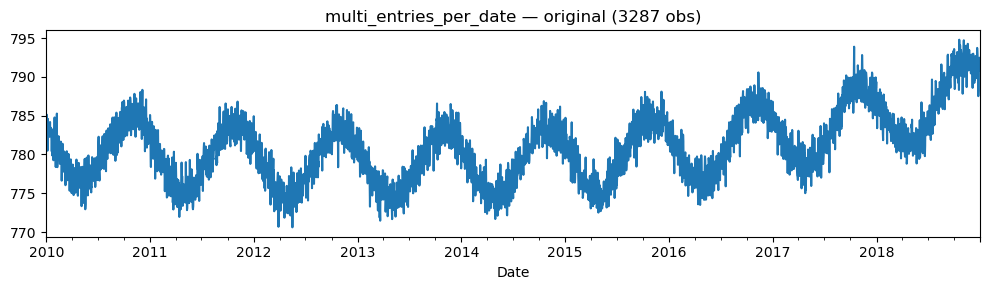

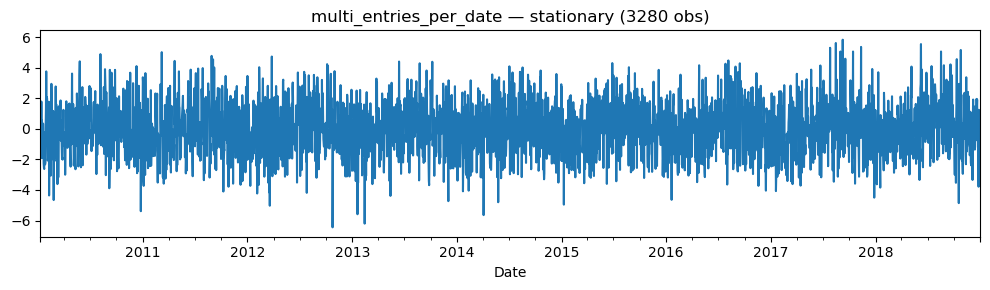

Step 3 ✓  nlags used 114/114 —  | nlags trimmed to 3*m=6 | PACF sig=[1, 3, 4, 5, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 42, 44, 45, 47, 49, 50, 56, 57, 63, 70, 76, 77, 83, 84, 89, 91, 97, 98, 105, 107, 112] | ACF sig=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 16, 17, 18, 20, 21, 22, 23, 24, 26, 29, 31, 32, 33, 34, 35, 36, 39, 44, 45, 49, 50, 53, 55, 56, 57, 58, 60, 68, 72, 78, 107, 110] | seasonality_check={'has_seasonality': True, 'm': 2, 'preference': 'mixed'}


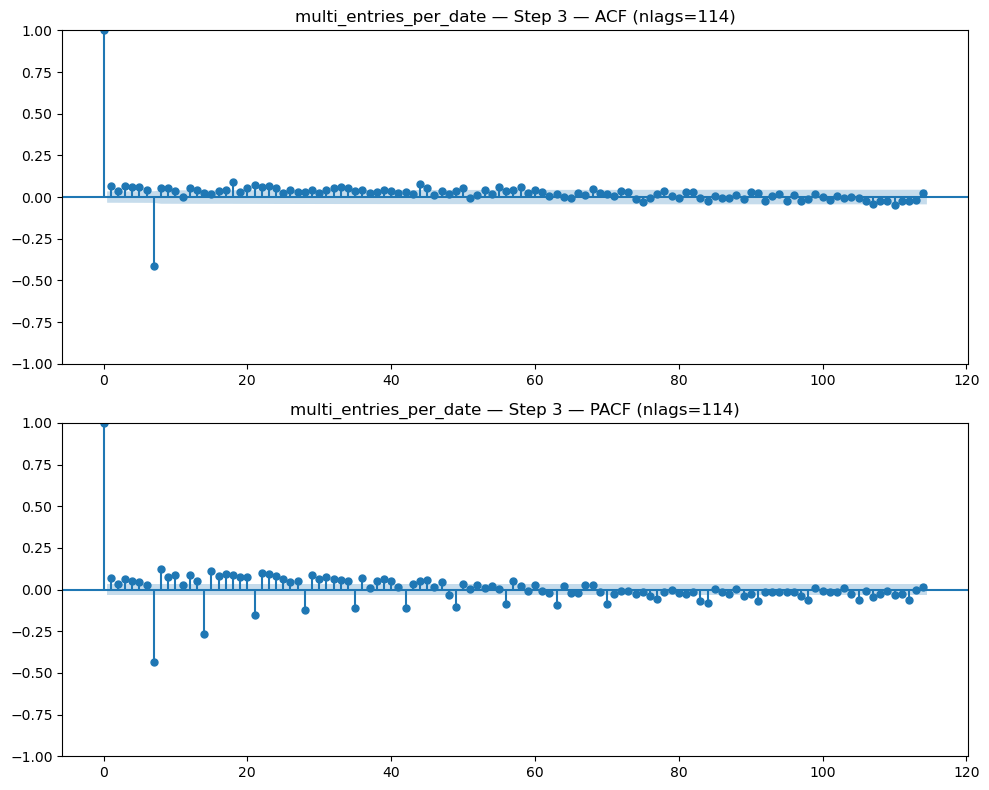

Step 4 ✓  Best AIC=12236.1 | Val MAPE=0.15% | Ljung–Box p=4.436249509735576e-90 | ARCH LM p=0.010555954918525635 | trend=n | order=(2, 0, 1)x(0,1,1,2)

=== Step 5 Validation Report ===
Model: order=(2, 0, 1) seasonal=(0, 1, 1, 2) trend=n
AIC=12236.1, Validation MAPE=0.15%
Ljung–Box p=4.436249509735576e-90 | ARCH p=0.010555954918525635 | JB p=0.5650104111244996 | AD p=0.2540023452492183 | DW=2.109243489224575


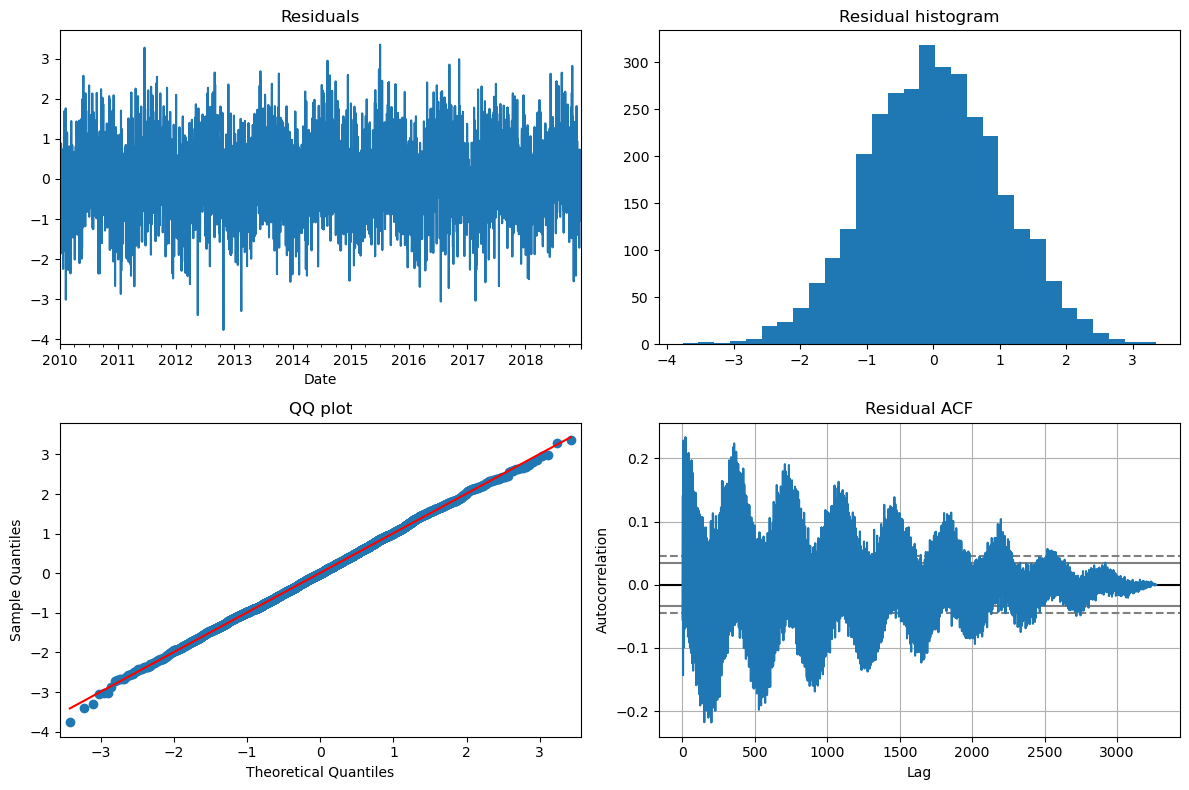

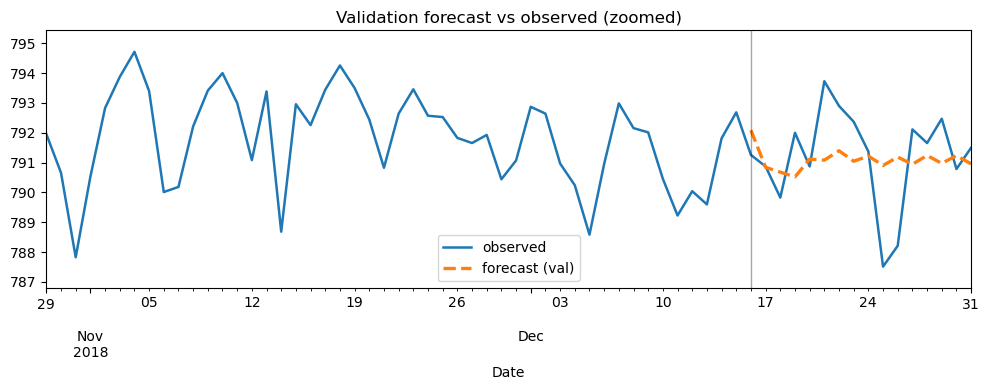

Step 5 ✓  Validation complete.


,forecast,lower,upper
2018-12-16,792.086706,789.010820,795.162591
2018-12-17,790.842525,787.589287,794.095763
2018-12-18,790.680666,787.395122,793.966210
2018-12-19,790.523449,787.155564,793.891334
2018-12-20,791.117814,787.744915,794.490714
2018-12-21,791.082880,787.709431,794.456328
2018-12-22,791.397575,787.895701,794.899449
2018-12-23,791.046963,787.534592,794.559335
2018-12-24,791.220815,787.607103,794.834528
2018-12-25,790.905844,787.292082,794.519605


Step 6 ✓  Produced table (table, h=300, used_model=True)

Original head:


,number_sold
Date,
2010-01-01,783.857143
2010-01-02,785.142857
2010-01-03,783.757143
2010-01-04,784.657143
2010-01-05,780.485714


Stationary head:


,number_sold
Date,
2010-01-08,-1.128571
2010-01-09,-1.771429
2010-01-10,0.128571
2010-01-11,-1.914286
2010-01-12,1.785714


------------------------------------------------------------------------------
[multi_entries_per_date] Summary → S1:✓ S2:✓ S3:✓ S4:✓ S5:✓ S6:✓
------------------------------------------------------------------------------

=== [stock_data_RITM] stock_test_RITM_1.csv ===
Step 1 ✓  Observations: 1,697 | Inferred freq: H
Step 2 ✓  ADF p(before)=0.5499513476733234, ADF p(after)=1.3491725748782341e-11 | Transform=none (shift=0.0000) | d=1, D=0, m=None


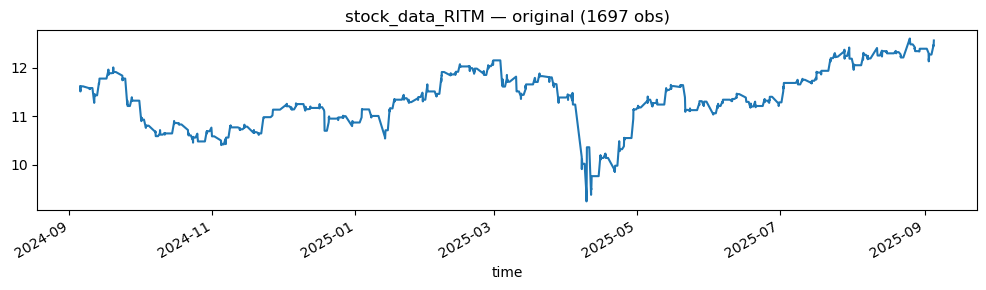

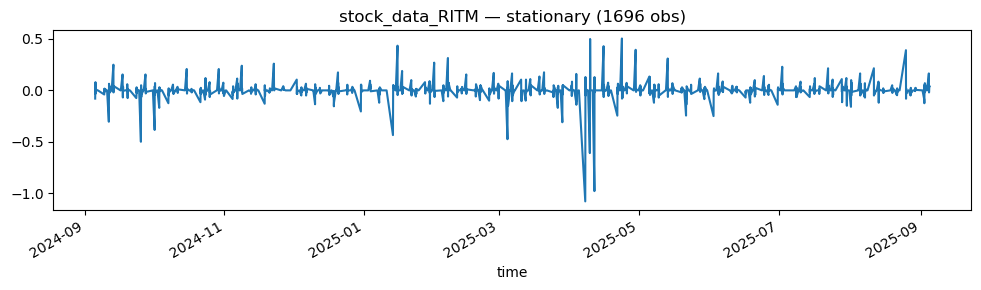

Step 3 ✓  nlags used 82/82 —  | nlags trimmed to 3*m=6 | PACF sig=[1, 3, 13, 16, 17, 26, 65, 78] | ACF sig=[1, 3, 13, 14, 16, 17, 18, 26, 65, 78] | seasonality_check={'has_seasonality': True, 'm': 2, 'preference': 'MA'}


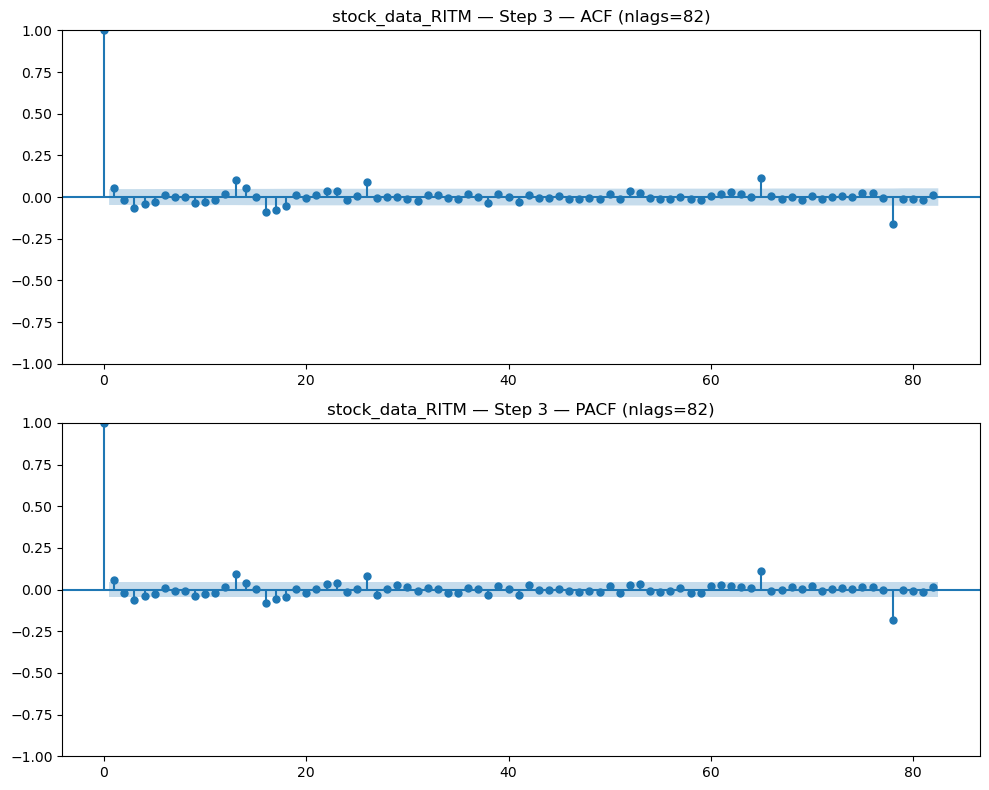

Step 4 ✓  Best AIC=-4238.1 | Val MAPE=1.17% | Ljung–Box p=0.9886995567669803 | ARCH LM p=0.46674035582573714 | trend=n | order=(2, 1, 1)x(0,0,1,2)

=== Step 5 Validation Report ===
Model: order=(2, 1, 1) seasonal=(0, 0, 1, 2) trend=n
AIC=-4238.1, Validation MAPE=1.17%
Ljung–Box p=0.9886995567669803 | ARCH p=0.46674035582573714 | JB p=0.0 | AD p=0.0 | DW=1.999686128061629


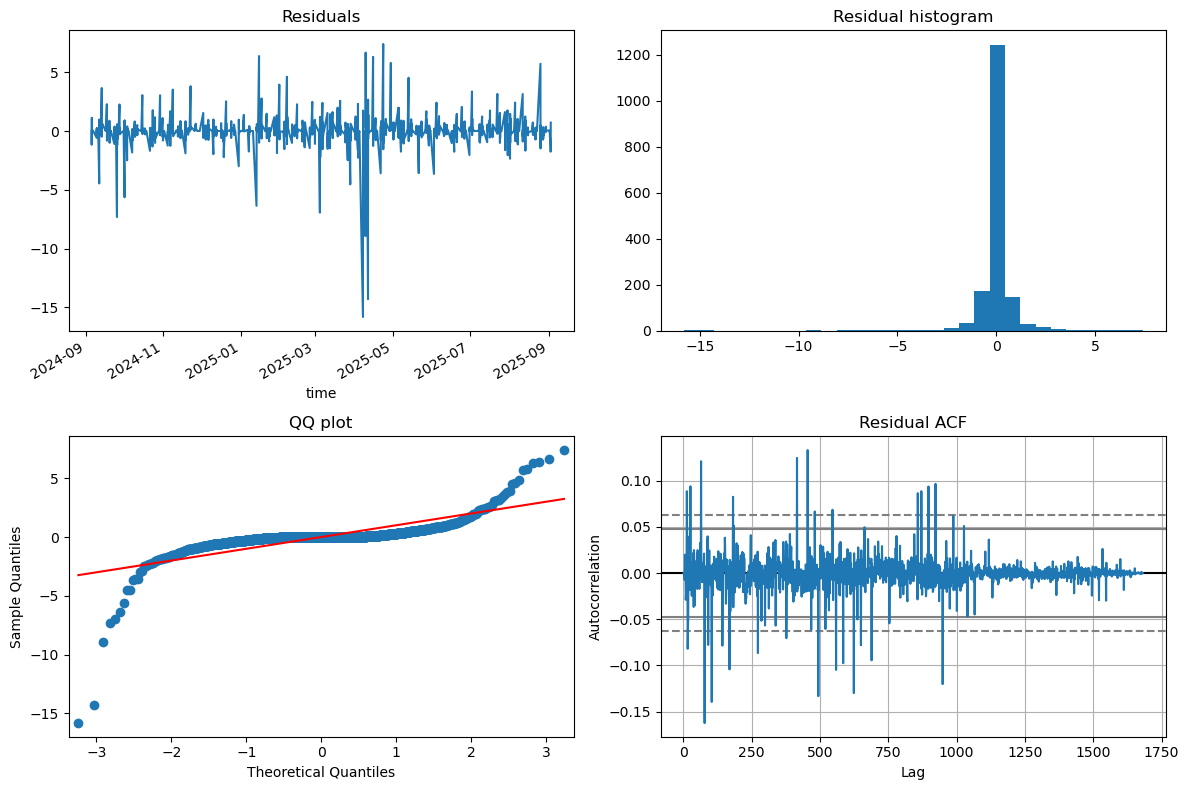

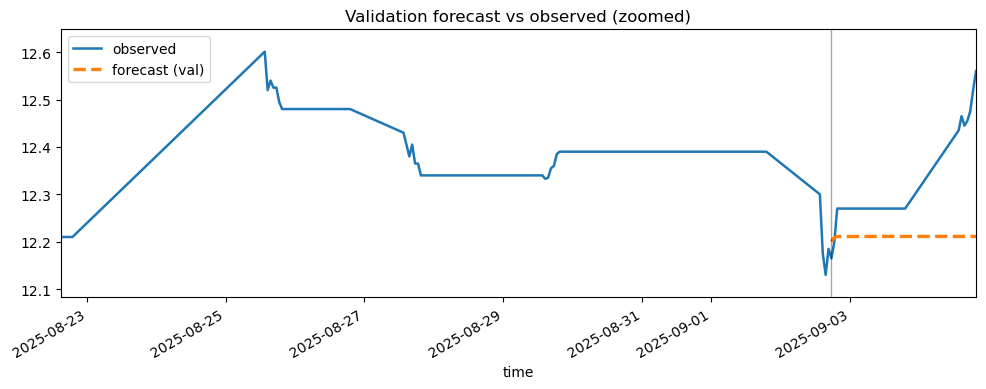

Step 5 ✓  Validation complete.
Predicted value @ 2025-09-04 20:30:00: 12.2  (CI: [12.07, 12.33])
Step 6 ✓  Produced value (value, h=1, used_model=True)

Original head:


,RITM
time,
2024-09-05 13:30:00,11.615
2024-09-05 14:30:00,11.535
2024-09-05 15:30:00,11.545
2024-09-05 16:30:00,11.510
2024-09-05 17:30:00,11.590


Stationary head:


,RITM
time,
2024-09-05 14:30:00,-0.080000
2024-09-05 15:30:00,0.010000
2024-09-05 16:30:00,-0.035000
2024-09-05 17:30:00,0.080000
2024-09-05 18:30:00,0.014999


------------------------------------------------------------------------------
[stock_data_RITM] Summary → S1:✓ S2:✓ S3:✓ S4:✓ S5:✓ S6:✓
------------------------------------------------------------------------------

Done. 2/2 cases completed.


In [41]:
# ================= Test bench (Steps 1→6) with zoomed validation & forecast charts =================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- If you already defined TEST_CASES earlier, this won't overwrite it. Otherwise, create a template.
if "TEST_CASES" not in globals():
    TEST_CASES = [
        {
            "name": "mixed_format_dates",
            "path": r"C:\path\to\time_series_unsorted.csv",
            "time_column": "Date",
            "target_column": "Revenue",
            "date_format": None,
            "aggregate": "last",
            "seasonal_period": None,
            "nlags": "auto",
            "request_text": "plot next 24 periods with 90% CI",
        },
        {
            "name": "multi_entries_per_date",
            "path": r"C:\path\to\train.csv",
            "time_column": "Date",
            "target_column": "number_sold",
            "date_format": None,
            "aggregate": "mean",
            "seasonal_period": None,
            "nlags": "auto",
            "request_text": "table next 12 periods with 95% CI",
        },
        {
            "name": "stock_data_RITM",
            "path": r"C:\path\to\stock_test_RITM_1.csv",
            "time_column": "time",
            "target_column": "RITM",
            "date_format": None,
            "aggregate": "last",
            "seasonal_period": None,
            "nlags": "auto",
            "request_text": "what is the predicted value on 2026-06-30 with 95% CI",
        },
    ]

# --- Helpers ---------------------------------------------------------------
def _auto_nlags(n: int) -> int:
    return max(10, int(2 * np.sqrt(max(1, n))))

def _nlags_val(nlags, y):
    return _auto_nlags(len(y.dropna())) if (isinstance(nlags, str) and nlags.lower()=="auto") else int(nlags)

def _print_line():
    print("-" * 78)

def _head(df_or_s, k=5):
    try:
        display(pd.DataFrame(df_or_s).head(k))
    except Exception:
        print(pd.DataFrame(df_or_s).head(k))

# ----------------- Run a single test case & report -------------------------
def report_case_full_zoomed(cfg, do_plot=True):
    name = cfg["name"]
    path = cfg["path"]
    time_col = cfg.get("time_column")
    target_col = cfg.get("target_column")
    date_format = cfg.get("date_format")
    aggregate = cfg.get("aggregate", "last")
    seasonal_period = cfg.get("seasonal_period")
    nlags_req = cfg.get("nlags", "auto")
    req_text = cfg.get("request_text", "plot next 12 periods")

    if not Path(path).exists():
        print(f"[{name}] ❌ File not found: {path}")
        return None

    print(f"\n=== [{name}] {Path(path).name} ===")
    step_ok = {k: False for k in range(1, 7)}
    pack = {"name": name}

    # ---------- Step 1 + Step 2 ----------
    try:
        s, stat, lags_info = ensure_stationarity_from_csv(
            csv=path,
            time_column_name=time_col,
            target_column_name=target_col,
            date_format=date_format,
            aggregate=aggregate,
            adf_alpha=0.05,
            max_d=2,
            seasonal_period=seasonal_period,
            try_variance_stabilize=True,
            compute_lag_suggestions=True,
            nlags=_nlags_val(nlags_req, pd.Series([0,1]))  # dummy; Step 2 recomputes on stationary series
        )
        step_ok[1] = True; step_ok[2] = True
    except Exception as e:
        print(f"[{name}] ❌ Step 1/2 failed: {e}")
        return None

    # Diagnostics for Steps 1–2
    adf_before = getattr(stat.adf_before, "pvalue", None) if stat.adf_before else None
    adf_after  = getattr(stat.adf_after, "pvalue", None) if stat.adf_after else None
    dmeta = stat.differencing; tmeta = stat.transform
    print(f"Step 1 ✓  Observations: {len(s):,} | Inferred freq: {s.attrs.get('inferred_freq')}")
    print(f"Step 2 ✓  ADF p(before)={adf_before}, ADF p(after)={adf_after} | "
          f"Transform={tmeta.method} (shift={getattr(tmeta,'shift',0):.4f}) | d={dmeta.d}, D={dmeta.D}, m={dmeta.m}")

    if do_plot:
        plt.figure(figsize=(10, 3)); s.plot(); plt.title(f"{name} — original ({len(s)} obs)"); plt.tight_layout(); plt.show()
        plt.figure(figsize=(10, 3)); stat.y_stationary.plot(); plt.title(f"{name} — stationary ({len(stat.y_stationary)} obs)"); plt.tight_layout(); plt.show()

    # ---------- Step 3: ACF/PACF + candidates ----------
    try:
        nlags_used_input = _nlags_val(nlags_req, stat.y_stationary)
        suggestions = suggest_sarimax_candidates(stat, nlags=nlags_used_input, max_p=3, max_q=3, max_P=1, max_Q=1)
        info = suggestions["summary"]
        step_ok[3] = True
        print(f"Step 3 ✓  nlags used {info.get('nlags_used')}/{info.get('nlags_requested')} "
              f"{('— ' + (info.get('note') or '')) if info.get('note') else ''} | "
              f"PACF sig={info.get('pacf_lags')} | ACF sig={info.get('acf_lags')} | "
              f"seasonality_check={suggestions.get('seasonality_check')}")
        if do_plot:
            plot_acf_pacf(stat.y_stationary, nlags=nlags_req, title_prefix=f"{name} — Step 3")
    except Exception as e:
        print(f"[{name}] ❌ Step 3 failed: {e}")
        return None

    # ---------- Step 4: Fit grid & pick best ----------
    try:
        pack4 = build_best_model_from_suggestions(s, stat, suggestions, val_h=None, verbose=False)
        best = pack4["best"]
        if not best or not best.get("fit_ok"):
            print(f"[{name}] ⚠️ Step 4 completed but no model fit successfully; continuing for diagnostics.")
        else:
            (p,d,q) = best["order"]; (P,D,Q,m) = best["seasonal_order"]; tr = best.get("trend")
            print(f"Step 4 ✓  Best AIC={best['aic']:.1f} | Val MAPE={best['mape_val']:.2f}% | "
                  f"Ljung–Box p={best['diagnostics'].get('lb_pvalue')} | ARCH LM p={best['diagnostics'].get('arch_pvalue')} | "
                  f"trend={tr} | order={(p,d,q)}x({P},{D},{Q},{m})")
        step_ok[4] = True
    except Exception as e:
        print(f"[{name}] ❌ Step 4 failed: {e}")
        return None

    # ---------- Step 5: Validate (ZOOMED) ----------
    try:
        best = pack4["best"]
        if best and best.get("fit_ok"):
            # 👇 key change: pass min_forecast_share=0.20 to make the validation forecast visible
            report = validate_model(s, stat, best, val_h=pack4["val_h"], alpha=0.05, plot=do_plot,
                                    min_forecast_share=0.20)  # 20% of x-axis
            step_ok[5] = True
            print("Step 5 ✓  Validation complete.")
        else:
            print(f"[{name}] ⚠️ Step 5 skipped (no valid model).")
    except Exception as e:
        print(f"[{name}] ❌ Step 5 failed: {e}")

    # ---------- Step 6: Fulfill request (chart/table/value) ----------
    try:
        best = pack4["best"] if pack4 else None
        if best and best.get("fit_ok"):
            out6 = fulfill_forecast_request(
                req_text, s, stat, best,
                default_h=12, default_conf=0.95, render=do_plot,
                # 👇 ensure Step-6 forecast chart is also visibly large
                min_forecast_share=0.20
            )
            step_ok[6] = True
            print(f"Step 6 ✓  Produced {out6['result_type']} "
                  f"({out6['intent']['mode']}, h={out6['h']}, used_model={out6['used_model']})")
        else:
            print(f"[{name}] ⚠️ Step 6 skipped (no valid model).")
    except Exception as e:
        print(f"[{name}] ❌ Step 6 failed: {e}")

    # ---------- Heads for quick inspection ----------
    print("\nOriginal head:"); _head(s)
    print("Stationary head:"); _head(stat.y_stationary)

    # ---------- Summary line ----------
    _print_line()
    flags = " ".join([f"S{k}:{'✓' if ok else '✗'}" for k, ok in step_ok.items()])
    print(f"[{name}] Summary → {flags}")
    _print_line()

    return {
        "name": name,
        "series": s,
        "stationary": stat,
        "suggestions": suggestions,
        "pack4": pack4,
        "steps_ok": step_ok,
    }

# ----------------------------- Run all tests -------------------------------
results = []
for cfg in TEST_CASES:
    out = report_case_full_zoomed(cfg, do_plot=True)
    if out is not None:
        results.append(out)

print(f"\nDone. {len(results)}/{len(TEST_CASES)} cases completed.")
